# SFT Fine-tuning GPT-4o for Chart Analysis

Learn how to fine-tune the **gpt-4o** model using Supervised Fine Tuning (SFT) with Python SDK to enhance images intrepretation.

This example demonstrates the process of vision fine-tuning of GPT-4-o leveraging a chart analysis benchmark dataset for visual and logical reasoning. It covers data preparation, fine-tuning, deployment, and evaluation against GPT-4-o's baseline performance.

Authors:
* He Zhang
* Marco Prado
* PG team

**Acknowledgements:**

* This notebook has been inspired by the [Microsoft PG Repository and demo](https://github.com/microsoft-foundry/fine-tuning/tree/main/Demos/Image_FT_Chart_Analysis)
* This project utilizes the ChartQA dataset introduced by Masry et al. in their paper, *ChartQA: A Benchmark for Question Answering about Charts with Visual and Logical Reasoning* (Findings of ACL 2022). We acknowledge the authors for providing this valuable resource. For more details, refer to the publication: [ChartQA: ACL 2022](https://aclanthology.org/2022.findings-acl.177).

### Prerequisites

* Learn the [what, why, and when to use fine-tuning.](https://learn.microsoft.com/en-us/azure/ai-services/openai/concepts/fine-tuning-considerations)
* An Azure subscription - [Create one for free.](https://azure.microsoft.com/free/cognitive-services)
* A [Microsoft Foundry project](https://learn.microsoft.com/en-us/azure/ai-foundry/how-to/create-projects) in Azure AI Foundry portal.
    * Fine-tuning access requires **Cognitive Services OpenAI Contributor** in the Microsoft Foundry resource.
    * A Microsoft Foundry resource created in a supported fine-tuning region (e.g. East US 2 or Sweden Central).
    * A model deployment of **gpt-4o** base model, named **gpt-4o**.  
* A Training and Validation datasets:
  * At least 50 high-quality samples (preferably 1,000s) are required.
  * Must be formatted in the JSON Lines (JSONL) document with UTF-8 encoding.
  * For this test notebook, we use he ChartQA dataset.
* Python version at least: **3.10**
* [Jupyter Notebooks](https://jupyter.org/) or **Visual Studio Code** with the **Jupyter** notebook extension installed.
* An `azure.env` file to store Azure credentials as environmental variables. **Be sure not to share this file with others or upload it to a public GitHub repository.**

### Step 1: Setup

#### Retrieve resources values

1. Go to your Microsoft Foundry resource in the Azure portal
1. In the **Overview** section, copy and save the following values:
    * Microsoft Foundry Resource Name
    * Resource group
    * Subscription ID

    <img src="../../images/screenshot-foundry-overview.png" alt="Screenshot of the Azure OpenAI resource management pane." width="800"/>
1. Go to **Resource Management**, click **Keys and Endpoint** sub-section
1. Click **OpenAI**
1. Copy and save the following values:
    * **KEY 1**
    * **Endpoint URL**. One of these endpoint links: **Language APIs**, **Dall-e APIs** or **Whisper APIs**

    <img src="../../images/screenshot-foundry-keys-and-endpoint.png" alt="Screenshot of the Azure OpenAI resource management pane." width="800"/>

#### Add credentials and variables

1. Rename the [azure.env.sample](azure.env.sample) to "**azure.env**".
1. Open the [azure.env](azure.env) file located in the "LLM-Fine-Tuning-Azure/labs/fine_tuning_notebooks/gpt_fine_tuning
/" folder.
1. Paste saved values to the variables in the file **azure.env**:
    * AZURE_OPENAI_ENDPOINT = "_<Foundry_Endpoint_URL>_"
    * AZURE_OPENAI_API_KEY = "_<Foundry_KEY_1>_"
    * SUBSCRIPTION_ID = "_<Foundry_Subscription_ID>_"
    * RESOURCE_NAME = "_<Foundry_Name>_"
    * RG_NAME = "_<Foundry_ResourceGroup_Name>_"
1. Save the file and close it. 

**Do not** distribute this file as this contains credential information! 

#### Install required Python libraries (if not done yet)

In [ ]:
%pip install -q openai pandas datasets pillow azure-identity tenacity matplotlib 

#### Authenticate the python environment with Azure

# Open the CLI and authenticate to azure

```
az login --use-device-code
```

#### Import required Python libraries 

In [1]:
import os
import json
from io import BytesIO, StringIO

import pandas as pd
from PIL import Image
import base64
import requests
from IPython.display import display, Markdown
from tqdm import tqdm
from tenacity import retry, stop_after_attempt, wait_fixed
from dotenv import load_dotenv, find_dotenv
from azure.identity import DefaultAzureCredential
import matplotlib.pyplot as plt

from datasets import load_dataset
from openai import AzureOpenAI

%config InlineBackend.figure_format = 'retina'

#### Load environmental variables to assign credentials 

In [ ]:
# Load env. file
load_dotenv("azure.env")

# Foundry model deployment using the Control Plane API
api_key = os.getenv("AZURE_OPENAI_API_KEY")
azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
subscription_id = os.getenv("SUBSCRIPTION_ID")
resource_name = os.getenv("RESOURCE_NAME") # name of the Foundry resource
rg_name = os.getenv("RESOURCE_GROUP") # name of the resource group

# Central variables
project_name, version = "chart-qa", "dev-01" # for naming files and models
ft_model_deployment = f"{project_name}-{version}" # the name of your fine-tuned model deployment
base_model_deployment = "gpt-4o" # deployment name (used for comparative evaluation)

# Dataset parameters
train_samples = 2000
val_samples = 500
test_samples = 500
bold_start, bold_end = '\033[1m', '\033[0m'

# System prompt for the Vision Language Model
SYSTEM_PROMPT = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanations unless absolutely necessary."""

# Initialize Azure OpenAI client
client = AzureOpenAI(
    api_key=api_key,
    api_version="2024-10-21",
    azure_endpoint=azure_endpoint
)

In [ ]:
# [OPTIONAL] Test the client with a simple chat completion
response = client.chat.completions.create(
	model="gpt-4o",
	messages=[
		{"role": "system", "content": "You are a helpful assistant."},
		{"role": "user", "content": "What is the capital of USA?"}
	],
	temperature=0
)

print(response.choices[0].message.content)

#### Define helper functions

In [ ]:
def encode_image(image, quality=95):
    """ Encode an image into a base64 string in JPEG format. """

    if image.mode != 'RGB':
        image = image.convert('RGB')  # Convert to RGB
    buffered = BytesIO()
    image.save(buffered, format="JPEG", quality=quality) 
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

def date_sorted_df(details_dict):
    """ Create a pandas DataFrame from a dictionary and sort it by a 'created' or 'created_at' timestamp column for displaying OpenAI API tables. """
    df = pd.DataFrame(details_dict)
    
    if 'created' in df.columns:
        df.rename(columns={'created': 'created_at'}, inplace=True)
    
    # Convert 'created_at' from Unix timestamp to human-readable date/time format
    df['created_at'] = pd.to_datetime(df['created_at'], unit='s').dt.strftime('%Y-%m-%d %H:%M:%S')

    if 'finished_at' in df.columns:
        # Convert 'finished_at' from Unix timestamp to human-readable date/time format, keeping null values as is
        df['finished_at'] = pd.to_datetime(df['finished_at'], unit='s', errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')
    
    # Sort DataFrame by 'created_at' in descending order
    df = df.sort_values(by='created_at', ascending=False)

    return df

def plot_learning_curves(df, smoothing_window=10):
    """
    Plots learning curves for a fine-tuning job with smoothing for train metrics.

    Parameters:
    df (pd.DataFrame): Dataframe containing the training and validation metrics.
    smoothing_window (int): Window size for rolling mean smoothing.
    """
    epochs = df[df['full_valid_loss'].notna()]['step'].values

    # Interpolate missing values for validation metrics
    df['valid_loss_interpolated'] = df['valid_loss'].interpolate()
    df['valid_mean_token_accuracy_interpolated'] = df['valid_mean_token_accuracy'].interpolate()

    # Compute smoothed train metrics
    df['train_loss_smoothed'] = df['train_loss'].rolling(window=smoothing_window, min_periods=1).mean()
    df['train_mean_token_accuracy_smoothed'] = df['train_mean_token_accuracy'].rolling(window=smoothing_window, min_periods=1).mean()

    # Initialize subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # Plot Train Loss
    axs[0, 0].plot(df['step'], df['train_loss'], label='Train Loss (Original)', linewidth=0.5, alpha=0.7)
    axs[0, 0].plot(df['step'], df['train_loss_smoothed'], label='Train Loss (Smoothed)', linewidth=2, color='blue')
    for epoch in epochs:
        axs[0, 0].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[0, 0].set_title("Train Loss")
    axs[0, 0].set_xlabel("Step")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].legend()

    # Plot Train Mean Token Accuracy
    axs[0, 1].plot(df['step'], df['train_mean_token_accuracy'], label='Train Mean Token Accuracy (Original)', linewidth=0.5, alpha=0.7, color='orange')
    axs[0, 1].plot(df['step'], df['train_mean_token_accuracy_smoothed'], label='Train Mean Token Accuracy (Smoothed)', linewidth=2, color='darkorange')
    for epoch in epochs:
        axs[0, 1].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[0, 1].set_title("Train Mean Token Accuracy")
    axs[0, 1].set_xlabel("Step")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].legend()

    # Plot Validation Loss
    axs[1, 0].plot(df['step'], df['valid_loss_interpolated'], label='Validation Loss', color='green')
    axs[1, 0].scatter(df['step'], df['full_valid_loss'], color='red', label='Full Validation Loss (Epoch)', edgecolor='black')
    for epoch in epochs:
        axs[1, 0].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[1, 0].set_title("Validation Loss")
    axs[1, 0].set_xlabel("Step")
    axs[1, 0].set_ylabel("Loss")
    axs[1, 0].legend()

    # Plot Validation Mean Token Accuracy
    axs[1, 1].plot(df['step'], df['valid_mean_token_accuracy_interpolated'], label='Validation Mean Token Accuracy', color='purple')
    axs[1, 1].scatter(df['step'], df['full_valid_mean_token_accuracy'], color='red', label='Full Validation Accuracy (Epoch)', edgecolor='black')
    for epoch in epochs:
        axs[1, 1].axvline(x=epoch, color='gray', linestyle='--', linewidth=0.5)
    axs[1, 1].set_title("Validation Mean Token Accuracy")
    axs[1, 1].set_xlabel("Step")
    axs[1, 1].set_ylabel("Accuracy")
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()


@retry(stop=stop_after_attempt(3), wait=wait_fixed(10))
def query_image(image, question, deployment):
    """ Query an image with a question using a specified deployment. """
    
    encoded_image_url = f"data:image/jpeg;base64,{encode_image(image, quality=95)}"

    response = client.chat.completions.create(
        model=deployment,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": [
                {"type": "text", "text": question},
                {"type": "image_url", "image_url": {"url": encoded_image_url}}
            ]}
        ],
        temperature=0,
        seed=0,
    )

    return response.choices[0].message.content


def compare(idx, df, base_model_deployment=base_model_deployment, ft_model_deployment=ft_model_deployment):
    """ Compare the performance of base and fine-tuned models on a given sample. """
    question = df.iloc[idx]['question']
    img = df.iloc[idx]['image']
    ground_truth_answer = df.iloc[idx]['answer']

    base_model_answer = query_image(img, question, base_model_deployment)
    ft_model_answer = query_image(img, question, ft_model_deployment)

    # Display the image
    display(img)

    # Display the question
    display(Markdown(f"**Question:** {question}"))
 
    print(f"Ground truth answer: {ground_truth_answer}")
    print(f"  - Base model answer (GPT-4o): {base_model_answer}")
    print(f"  - Fine-tuned model answer: {ft_model_answer}")

### Step 2: Retrieve and Prepare Training & Validation Datasets

Fine-tuning for images is possible with JSONL dataset files similar to the process of sending images as input to the chat completion API.
Images can be provided as HTTP URLs (as shown below) or data URLs containing base64-encoded images.

```json
{
  "messages": [
    { "role": "system", "content": "You are an assistant that identifies uncommon cheeses." },
    { "role": "user", "content": "What is this cheese?" },
    { "role": "user", "content": [
        {
          "type": "image_url",
          "image_url": {
            "url": "https://upload.wikimedia.org/wikipedia/commons/3/36/Danbo_Cheese.jpg"
          }
        }
      ]
    },
    { "role": "assistant", "content": "Danbo" }
  ]
}
```
The following cell converts the ChartQA dataset from HuggingFace into this JSONL format by using base64-encoded images. Depending on your training data format, you will likely need to perform a few changes for reusing the code for your other use cases. 

In [ ]:
# Load the ChartQA dataset
ds = load_dataset("HuggingFaceM4/ChartQA")
print("Original dataset:")
display(ds)

# Convert to pandas dataframe
ds_train = ds['train'].to_pandas()
ds_val = ds['val'].to_pandas()
ds_test = ds['test'].to_pandas()

# Consider only human-labelled images
ds_train = ds_train[ds_train['human_or_machine']==0]
ds_val = ds_val[ds_val['human_or_machine']==0]
ds_test = ds_test[ds_test['human_or_machine']==0]

# Sample training, validation, and test examples
ds_train = ds_train.sample(train_samples, random_state=42)
ds_val = ds_val.sample(val_samples, random_state=42)
ds_test = ds_test.sample(test_samples, random_state=42)

# Convert byte strings to PIL images. Retains original quality 
ds_train['image'] = ds_train['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))
ds_val['image'] = ds_val['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))
ds_test['image'] = ds_test['image'].apply(lambda x: Image.open(BytesIO(x['bytes'])))

# Convert array type of 'label' column into string only if the current data type is object
if ds_train['label'].dtype == 'object':
    ds_train['label'] = ds_train['label'].apply(lambda x: x[0])

if ds_val['label'].dtype == 'object':
    ds_val['label'] = ds_val['label'].apply(lambda x: x[0])

if ds_test['label'].dtype == 'object':
    ds_test['label'] = ds_test['label'].apply(lambda x: x[0])

# Rename columns
ds_train = ds_train.rename(columns={'query': 'question', 'label': 'answer'})
ds_val = ds_val.rename(columns={'query': 'question', 'label': 'answer'})
ds_test = ds_test.rename(columns={'query': 'question', 'label': 'answer'})

print("Fine-tuning scope:\n")
print(f"Training examples: {ds_train.shape[0]}")
print(f"Validation examples: {ds_val.shape[0]}")
print(f"Test examples: {ds_test.shape[0]}")

Original dataset:


DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 28299
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 1920
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 2500
    })
})

Fine-tuning scope:

Training examples: 2000
Validation examples: 500
Test examples: 500


QUESTION: Is the median of green bars and blue bars equal?


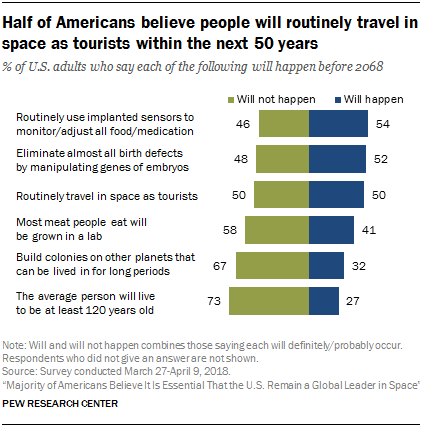

ANSWER: No


In [ ]:
# Review a random training example
idx=0

print('QUESTION:', ds_train.iloc[idx]['question'])
display(ds_train.iloc[idx]['image'])

print('ANSWER:', ds_train.iloc[idx]['answer'])

In [8]:
# Create dataset splits as local JSONL files compatible with the fine-tuning API
splits = ['train', 'val', 'test']
datasets = [ds_train, ds_val, ds_test]

for split, dataset in zip(splits, datasets):
    dataset_file = f"{project_name}-{version}-{split}.jsonl"
    print(f"Generating {dataset_file} with {dataset.shape[0]} samples.")
    
    json_data = []
    base64_prefix = "data:image/jpeg;base64,"
    
    for idx, example in tqdm(enumerate(dataset.itertuples()), total=dataset.shape[0]):
        try:
            system_message = {"role": "system", "content": SYSTEM_PROMPT}
            
            encoded_image = encode_image(example.image, quality=95)
            user_message = {
                "role": "user",
                "content": [
                    {"type": "text", "text": f"Question [{idx}]: {example.question}"},
                    {"type": "image_url", "image_url": {"url": f"{base64_prefix}{encoded_image}"}}
                ]
            }
            assistant_message = {"role": "assistant", "content": example.answer}

            json_data.append({"messages": [system_message, user_message, assistant_message]})
        except KeyError as e:
            print(f"Missing field in example {idx}: {e}")
        except Exception as e:
            print(f"Error processing example {idx}: {e}")
    
    with open(dataset_file, "w") as f:
        for message in json_data:
            json.dump(message, f)
            f.write("\n")

Generating chart-qa-dev-01-train.jsonl with 2000 samples.


100%|██████████| 2000/2000 [00:21<00:00, 94.88it/s] 


Generating chart-qa-dev-01-val.jsonl with 500 samples.


100%|██████████| 500/500 [00:05<00:00, 86.52it/s] 


Generating chart-qa-dev-01-test.jsonl with 500 samples.


100%|██████████| 500/500 [00:05<00:00, 86.38it/s] 


### Step 3: Upload Datasets for Fine-Tuning

In [ ]:
# Upload training file
train_file = client.files.create(
  file=open(f"{project_name}-{version}-train.jsonl", "rb"),
  purpose="fine-tune"
)

# Upload validation file
val_file = client.files.create(
  file=open(f"{project_name}-{version}-val.jsonl", "rb"),
  purpose="fine-tune"
)

### Step 4: Configure and Start Fine-Tuning Job

Here is some guidance if you want to adjust the hyperparameters of the fine-tuning process. You can keep them as `None` to use default values. 

| Hyperparameter                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `Batch size`                            | The batch size to use for training. When set to default, batch_size is calculated as 0.2% of examples in training set and the max is 256.                                                           |
| `Learning rate multiplier` | The fine-tuning learning rate is the original learning rate used for pre-training multiplied by this multiplier. We recommend experimenting with values between 0.5 and 2. Empirically, we've found that larger learning rates often perform better with larger batch sizes. Must be between 0.0 and 5.0. |
| `Number of epochs`       | Number of training epochs. An epoch refers to one full cycle through the data set. If set to default, number of epochs will be determined dynamically based on the input data. |
| `Seed`  | The seed controls the reproducibility of the job. Passing in the same seed and job parameters should produce the same results, but may differ in rare cases. If a seed is not specified, one will be generated for you. |

In [ ]:
# Create fine tuning job
file_train = train_file.id
file_val = val_file.id

suffix = f"{project_name}-{version}"

ft_job = client.fine_tuning.jobs.create(
  suffix=suffix,
  training_file=file_train,
  validation_file=file_val, # optional
  model="gpt-4o", # base model name or existing checkpoint (not the deployment name)
  seed=None,
  method={
      "type" : "supervised",
      "supervised" : {"hyperparameters" : {"n_epochs" : None,
                      "batch_size" : None,
                      "learning_rate_multiplier" : None,}
       }
  }
)

### Step 5: Track Fine-Tuning Job Status

In [ ]:
# List 5 recent fine-tuning jobs
ft_jobs = client.fine_tuning.jobs.list(limit=5).to_dict()

display(date_sorted_df(pd.DataFrame(ft_jobs['data'])))

,id,created_at,fine_tuned_model,finished_at,hyperparameters,model,object,result_files,seed,status,trained_tokens,training_file,validation_file,estimated_finish,suffix
0,ftjob-17d310978a6449a79c965f7d10fd3124,2026-02-05 02:40:15,gpt-4o-2024-08-06.ft-17d310978a6449a79c965f7d1...,2026-02-05 07:47:46,"{'batch_size': 4, 'learning_rate_multiplier': ...",gpt-4o-2024-08-06,fine_tuning.job,[file-0b602464d2d34d4b8c700fabb5a55eec],2121265116,succeeded,129488088,file-9424599942e44fdb97e745380770ae8c,file-9454851646444ec49395f0d65c3611be,1770279896,chart-qa-dev-01
1,ftjob-779f300115a4485ca06006bae0bd3dc9,2025-12-19 05:11:42,o4-mini-2025-04-16.ft-779f300115a4485ca06006ba...,2025-12-19 13:54:06,"{'batch_size': 32, 'learning_rate_multiplier':...",o4-mini-2025-04-16,fine_tuning.job,[file-7c2aa8978fc14a85a2af09fe1d5bd6b0],1401276792,succeeded,7879,file-64747fc8231c4c7daac9ec91aadebd89,file-faace3244366468ba567b4aaccf7de60,1766122422,NaN
2,ftjob-2bc13a5406184ef38716c6696dff0f8c,2025-12-16 01:23:53,gpt-4o-2024-08-06.ft-2bc13a5406184ef38716c6696...,2025-12-16 02:26:28,"{'batch_size': 32, 'learning_rate_multiplier':...",gpt-4o-2024-08-06,fine_tuning.job,[file-77fad101d6fd4af88acb6982a18ea956],3,succeeded,1035,file-059b8a047d534eddb0d9d721ed8fa73f,file-dc27a613f4714c79893f9a1d6d62acb0,1765849134,gpt4_o_dpo_ft
3,ftjob-6302ace3f76e4f139043df3513a8cca9,2025-11-18 23:12:38,gpt-4o-2024-08-06.ft-6302ace3f76e4f139043df351...,2025-11-19 13:29:26,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4o-2024-08-06,fine_tuning.job,[file-a0cc3769ab854a59a74cad5e3e30546d],3,succeeded,60405,file-dfae6556687f4237951da763423cbba5,file-07db5796046c46df84926456b23d7d0d,1763509705,gpt4o-text-dpo-ft-200-samples-qa
4,ftjob-aa2476a2844a49f68ea84678ebdda63b,2025-11-11 04:28:01,gpt-4.1-mini-2025-04-14.ft-aa2476a2844a49f68ea...,2025-11-11 05:30:27,"{'batch_size': 1, 'learning_rate_multiplier': ...",gpt-4.1-mini-2025-04-14,fine_tuning.job,[file-8e81509a27014c129937806be742ad4d],1298750476,succeeded,244746,file-8c05b3dc7a7147ae9a9aaf5d2fe65ead,file-87e636f122dd48819c069f460a5c41bf,1762841168,TextGSM8K


In [ ]:
# Retrieve the job ID from the fine-tuning job
ft_job_id = ft_job.to_dict()['id']

In [ ]:
# Retrieve a specific job result using the job ID
ft_job_result = client.fine_tuning.jobs.retrieve('ftjob-17d310978a6449a79c965f7d10fd3124') # replace "ftjob-0a4c..." with the actual job-id in your list

#### Retrieve fine-tuning metrics

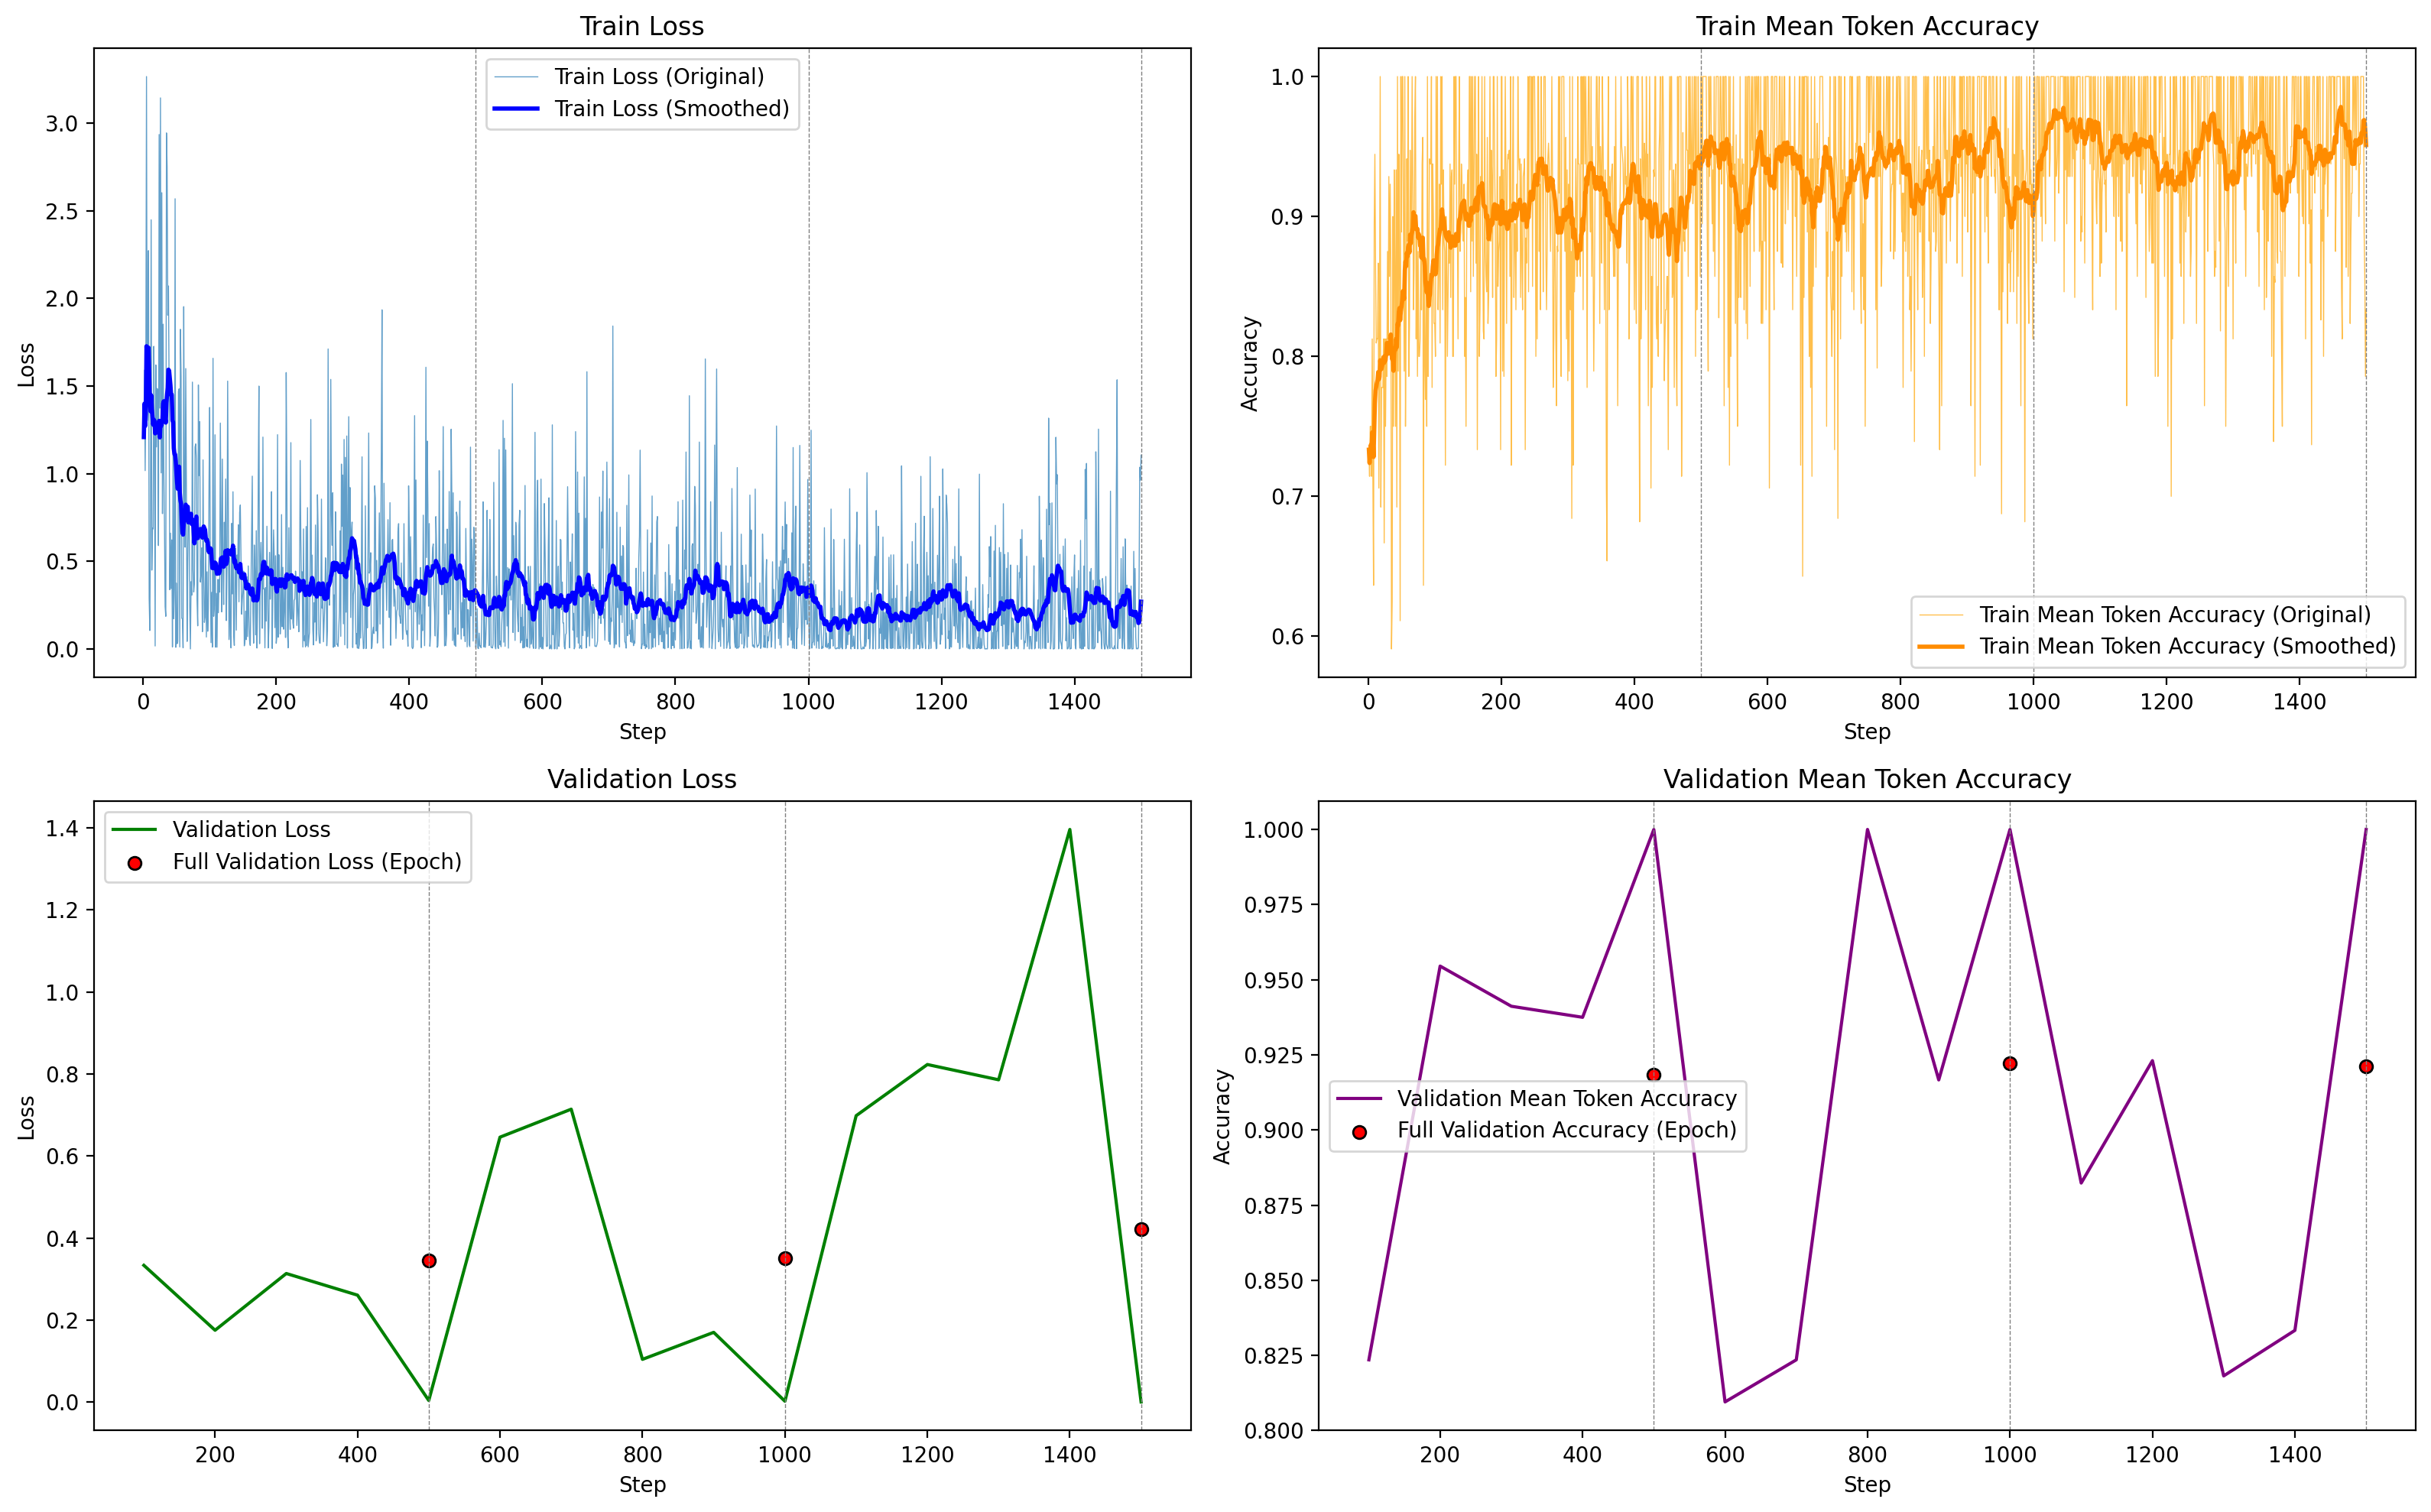

In [ ]:
# Retrieve fine-tuning metrics from result file
result_file_id = ft_job_result.result_files[0]
results_content = client.files.content(result_file_id).content.decode()

data_io = StringIO(results_content)

results_df = pd.read_csv(data_io)

plot_learning_curves(results_df, smoothing_window=20)

Take a look at this table for an interpretation of above diagrams:  

| Metric                       | Description                                                                                                                                                                              |
|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `step`                            | The number of the training step. A training step represents a single pass, forward and backward, on a batch of training data.                                                           |
| `train_loss`, `validation_loss` | The loss for the training / validation batch |
| `train_mean_token_accuracy`       | The percentage of tokens in the training batch correctly predicted by the model. For example, if the batch size is set to 3 and your data contains completions [[1, 2], [0, 5], [4, 2]], this value is set to 0.83 (5 of 6) if the model predicted [[1, 1], [0, 5], [4, 2]]. |
| `validation_mean_token_accuracy`  | The percentage of tokens in the validation batch correctly predicted by the model. For example, if the batch size is set to 3 and your data contains completions [[1, 2], [0, 5], [4, 2]], this value is set to 0.83 (5 of 6) if the model predicted [[1, 1], [0, 5], [4, 2]]. |

### Step 6: Deploy the Fine-Tuned Model

The code below shows how to deploy the model using the Control Plane API. Take a look at the [Azure OpenAI fine-tuning documentation](https://learn.microsoft.com/en-us/azure/ai-services/openai/how-to/fine-tuning?tabs=turbo&pivots=programming-language-python#deploy-fine-tuned-model) for more details.

In [ ]:
# List existing models
my_models = client.models.list().to_dict()

models_df = date_sorted_df(my_models['data'])

cols = ['status', 'capabilities', 'lifecycle_status', 'id', 'created_at', 'model']
print(f'Models of Foundry resource {bold_start}{resource_name}{bold_end}:')
display(models_df[cols].head())

**Note**: 
* The CLI running this code must already be authenticated using the _az login_ command.
* the _az login_ command was executed at the beginning of this notebook. Re-run if necessary.

In [15]:
fine_tuned_model = ft_job_result.fine_tuned_model # retrieve this value from the previous calls. Can also be a checkpoint name.

credential = DefaultAzureCredential()
token = credential.get_token("https://management.azure.com/.default").token

deploy_params = {'api-version': "2024-10-01"} 
deploy_headers = {'Authorization': 'Bearer {}'.format(token), 'Content-Type': 'application/json'}

deploy_data = {
    "sku": {"name": "GlobalStandard", "capacity": 100}, # in 1000 tokens per min
    "properties": {
        "model": {
            "format": "OpenAI",
            "name": fine_tuned_model, 
            "version": "1"
        }
    }
}
deploy_data = json.dumps(deploy_data)

request_url = f'https://management.azure.com/subscriptions/{subscription_id}/resourceGroups/{rg_name}/providers/Microsoft.CognitiveServices/accounts/{resource_name}/deployments/{ft_model_deployment}'

print('Creating a new deployment...')

r = requests.put(request_url, params=deploy_params, headers=deploy_headers, data=deploy_data)

print(r)
print(r.reason)
print(r.json())

Creating a new deployment...
<Response [200]>
OK
{'id': '/subscriptions/bccef1c9-0504-4d7d-a288-89e0c3588081/resourceGroups/rg_ai/providers/Microsoft.CognitiveServices/accounts/aifoundrymp/deployments/chart-qa-dev-01', 'type': 'Microsoft.CognitiveServices/accounts/deployments', 'name': 'chart-qa-dev-01', 'sku': {'name': 'GlobalStandard', 'capacity': 100}, 'properties': {'model': {'format': 'OpenAI', 'name': 'gpt-4o-2024-08-06.ft-17d310978a6449a79c965f7d10fd3124-chart-qa-dev-01', 'version': '1'}, 'versionUpgradeOption': 'NoAutoUpgrade', 'currentCapacity': 100, 'capabilities': {'area': 'US', 'chatCompletion': 'true', 'assistants': 'true', 'jsonSchemaResponse': 'true', 'maxContextToken': '128000', 'maxOutputToken': '16384', 'responses': 'true', 'agentsV2': 'true'}, 'provisioningState': 'Succeeded', 'rateLimits': [{'key': 'request', 'renewalPeriod': 10, 'count': 100}, {'key': 'token', 'renewalPeriod': 60, 'count': 100000}]}, 'systemData': {'createdBy': 'admin@MngEnvMCAP409633.onmicrosoft.c

### Step 7: Test the Deployed Fine-Tuned Model

In [ ]:
# Test the fine-tuned model on a sample from the test set. Question #1.
idx = 1

question = ds_test.iloc[idx]['question']
img = ds_test.iloc[idx]['image']
ground_truth_answer = ds_test.iloc[idx]['answer']

display(img)
print(f"Question: {question}")
print(f"Ground truth answer: {ground_truth_answer}")

predicted_answer = query_image(img, question, ft_model_deployment)
print(f"Predicted answer: {predicted_answer}")

### Step 8: Evaluate the Base GPT-4o and the DPO Fine-Tuned GPT-4o Models

In [ ]:
# Compare predictions from both models. Question #1.
compare(1, ds_test) # both models correct

In [ ]:
# Compare predictions from both models. Question #20.
compare(20, ds_test)

In [ ]:
# Compare predictions from both models. Question #31.
compare(31, ds_test)

In [ ]:
# Process test dataset with baseline model
ds_test['base-pred'] = ds_test.apply(lambda row: query_image(row['image'], row['question'], base_model_deployment), axis=1)

In [ ]:
# Process test dataset with fine-tuned model
ds_test['ft-pred'] = ds_test.apply(lambda row: query_image(row['image'], row['question'], ft_model_deployment), axis=1)

In [ ]:
# Use GPT-4o as judge LLM

EVAL_SYSTEM_PROMPT = """
Your task is to evaluate whether a predicted answer matches the ground truth answer, with the following considerations:

- The predicted answer may use different wording or phrasing but should convey the same meaning.
- Units (e.g., %, km, etc.) may be added to or omitted from the predicted answer compared to the ground truth.
- Variations in thousand delimiters or formatting are irrelevant.
- If the ground truth answer is a plain number (e.g., `x`) and the predicted answer includes a percentage sign (e.g., `x%`), it should still be considered correct if the meaning is equivalent.
- Minor numerical differences after the first digit are acceptable and should not be considered incorrect.

Assume the ground truth answer is factually correct. Your sole focus is to determine if the predicted answer matches the ground truth answer in meaning, including any acceptable unit additions.

You will be provided with:
1. The original question.
2. The ground truth answer.
3. The predicted answer.

Respond with one of the following:
- CORRECT: If the predicted answer matches the ground truth answer in meaning
- INCORRECT: If the predicted answer does not match the ground truth answer in meaning.
"""

@retry(stop=stop_after_attempt(3), wait=wait_fixed(10))
def evaluate(question, ground_truth_answer, predicted_answer, deployment=base_model_deployment):

    user_prompt = f"Original question: {question} \nGround truth answer: {ground_truth_answer}\nPredicted answer: {predicted_answer}" 

    response = client.chat.completions.create(
        model=deployment,
        messages=[
            {"role": "system", "content": EVAL_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0,
    )

    return response.choices[0].message.content

In [ ]:
print(evaluate('what is the diagram title?', 'comparison of tax rates in US states', 'Tax Rate Comparison Across US States'))
print(evaluate('What is the sum of negative answers?', '33.23', '33.2'))
print(evaluate('What is the sum of negative answers?', '33', '33%'))
print(evaluate('What is the sum of negative answers?', '33%', '33'))

In [ ]:
# Validate prediction accuracy of baseline model
ds_test['base-eval'] = ds_test.apply(lambda row: evaluate(row['question'], row['answer'], row['base-pred'], base_model_deployment), axis=1)

In [ ]:
# Validate prediction accuracy of fine-tuned model. Note: Using the base model as judge LLM in this cell is intended.
ds_test['ft-eval'] = ds_test.apply(lambda row: evaluate(row['question'], row['answer'], row['ft-pred'], base_model_deployment), axis=1)

In [ ]:
base_correct_count = ds_test['base-eval'].value_counts().get("CORRECT", 0)
base_eval_observations = ds_test.shape[0]
ft_correct_count = ds_test['ft-eval'].value_counts().get("CORRECT", 0)
ft_eval_observations = ds_test.shape[0]

chart_data = {
    'title' : 'GPT-4o ChartQA accuracy - baseline vs fine-tuned model', 
    'baseline' : 'GPT-4o',
    'fine-tuned' : 'GPT-4o fine-tuned',
    'baseline accuracy' : base_correct_count / base_eval_observations,
    'fine-tuned accuracy' : ft_correct_count / ft_eval_observations
    
}

# Extract data for plotting
models = [chart_data['baseline'], chart_data['fine-tuned']]
accuracies = [chart_data['baseline accuracy'], chart_data['fine-tuned accuracy']]

# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green'])

# Add titles and labels
plt.title(chart_data['title'])
plt.ylabel('Accuracy')
plt.xlabel('Model')

# Annotate bars with accuracy values
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center', fontsize=10)

# Display the chart
plt.tight_layout()
plt.show()


### Step 9: Delete the Deployment

It is **strongly recommended** that once you're done with this tutorial and have tested a few chat completion calls against your fine-tuned model, that you delete the model deployment, since the fine-tuned / customized models have an [hourly hosting cost](https://azure.microsoft.com/zh-cn/pricing/details/cognitive-services/openai-service/#pricing) associated with them once they are deployed.